# Motion Detection

In [6]:
!pip install opencv-python-headless numba

In [7]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import cv2
import numpy as np

def capture_frame():
    js = Javascript('''
    async function capture() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(video);
        video.srcObject = stream;
        await video.play();

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks()[0].stop();
        video.remove();

        return canvas.toDataURL('image/jpeg');
    }
    capture();
    ''')
    display(js)
    data = eval_js('capture()')
    binary = base64.b64decode(data.split(',')[1])
    image = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(image, cv2.IMREAD_COLOR)

In [13]:
from numba import cuda

@cuda.jit
def motion_detection_kernel(frame1, frame2, output, threshold):
    x, y = cuda.grid(2)

    if x < frame1.shape[0] and y < frame1.shape[1]:
        diff = 0

        for c in range(3):  # RGB channels
            diff += abs(int(frame1[x, y, c]) - int(frame2[x, y, c]))

        if diff > threshold:
            output[x, y] = 255
        else:
            output[x, y] = 0

<IPython.core.display.Javascript object>

Frame 1


<IPython.core.display.Javascript object>

Detected Motion Frame:


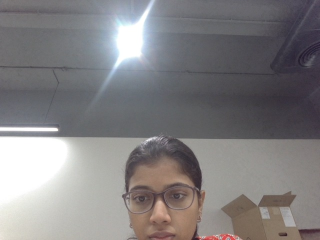

Motion Mask:


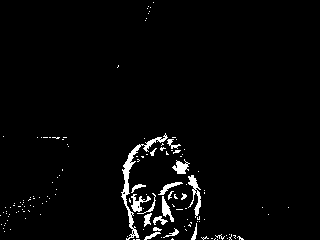

Frame 2


<IPython.core.display.Javascript object>

Detected Motion Frame:


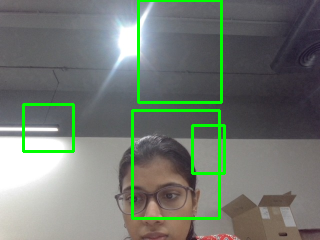

Motion Mask:


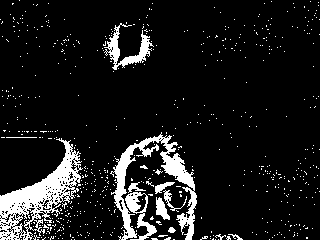

Frame 3


<IPython.core.display.Javascript object>

Detected Motion Frame:


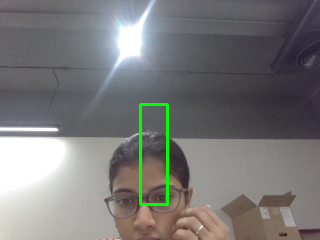

Motion Mask:


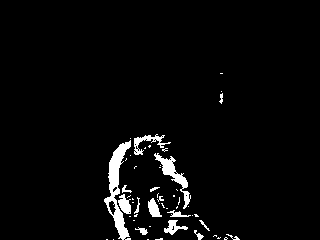

Frame 4


<IPython.core.display.Javascript object>

Detected Motion Frame:


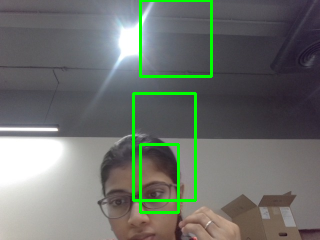

Motion Mask:


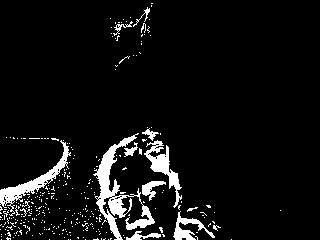

Frame 5


<IPython.core.display.Javascript object>

Detected Motion Frame:


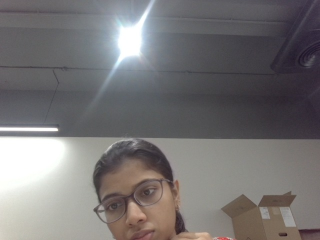

Motion Mask:


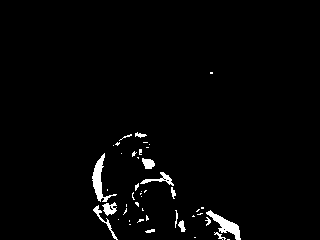

Frame 6


<IPython.core.display.Javascript object>

Detected Motion Frame:


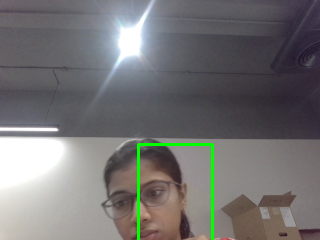

Motion Mask:


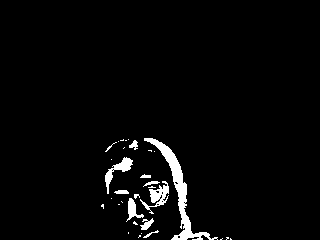

Frame 7


<IPython.core.display.Javascript object>

Detected Motion Frame:


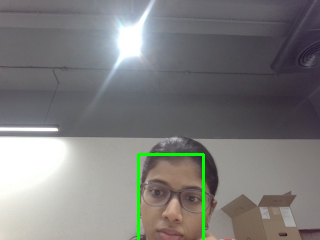

Motion Mask:


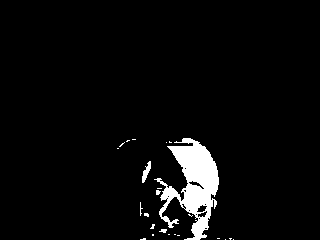

Frame 8


<IPython.core.display.Javascript object>

Detected Motion Frame:


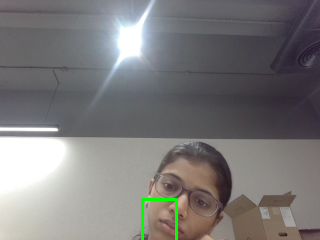

Motion Mask:


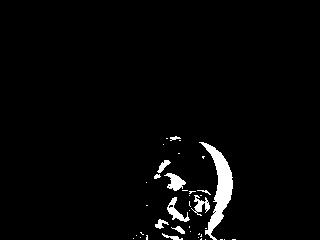

Frame 9


<IPython.core.display.Javascript object>

Detected Motion Frame:


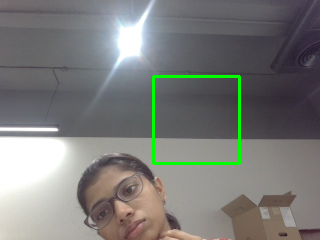

Motion Mask:


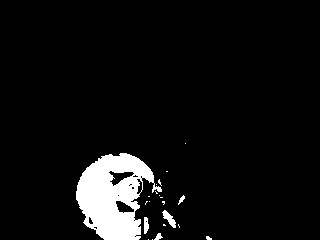

Frame 10


<IPython.core.display.Javascript object>

Detected Motion Frame:


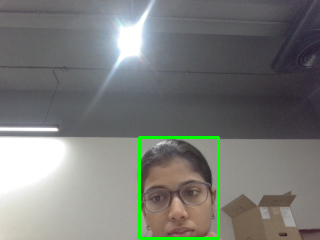

Motion Mask:


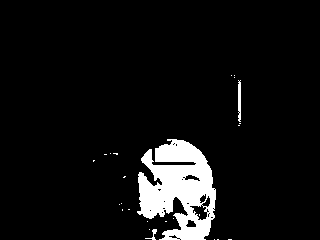

In [14]:
from google.colab.patches import cv2_imshow
import time

# Capture first frame
prev_frame = capture_frame()
prev_frame = cv2.resize(prev_frame, (320, 240))

# Run limited frames (important for Colab)
for i in range(10):

    print(f"Frame {i+1}")

    # Capture new frame
    frame = capture_frame()
    frame = cv2.resize(frame, (320, 240))

    # Output mask
    motion_mask = np.zeros((240, 320), dtype=np.uint8)

    # Send to GPU
    d_frame1 = cuda.to_device(prev_frame)
    d_frame2 = cuda.to_device(frame)
    d_output = cuda.to_device(motion_mask)

    # CUDA config
    threads_per_block = (16, 16)
    blocks_per_grid_x = int(np.ceil(240 / 16))
    blocks_per_grid_y = int(np.ceil(320 / 16))
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # Run CUDA kernel
    motion_detection_kernel[blocks_per_grid, threads_per_block](
        d_frame1, d_frame2, d_output, 50
    )

    # Copy back
    motion_mask = d_output.copy_to_host()

    # Find moving regions
    contours, _ = cv2.findContours(
        motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw bounding boxes
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(frame, (y, x), (y+w, x+h), (0, 255, 0), 2)

    # ✅ Display (Colab compatible)
    print("Detected Motion Frame:")
    cv2_imshow(frame)

    print("Motion Mask:")
    cv2_imshow(motion_mask)

    # Update previous frame
    prev_frame = frame.copy()

    # Small delay (important)
    time.sleep(0.5)